### Lesson 2: LangGraph Components

In [24]:
# !pip install langgraph
# !pip install langchain
# !pip install langchain_community
# !pip install langchain_openai
# !pip install pygraphviz
# !pip install langchain_google_genai


In [1]:
import os 
from dotenv import load_dotenv

load_dotenv()

gemini_api_key = os.getenv('GEMINI_API_KEY')
openai_api_key = os.getenv('OPENAI_API_KEY')

In [3]:
from langgraph.graph import StateGraph, END
from typing import Annotated, TypedDict
import operator
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage
from langchain_community.tools.tavily_search import TavilySearchResults

In [27]:
# llm = ChatOpenAI(
#     model="phi3",
#     temperature=0.7,
#     api_key=openai_api_key,
#     base_url=openai_base_url,

# )

# response = llm.invoke("Explain LangChain in simple terms.")
# print(response.content)

# from langchain_community.chat_models import ChatOllama

# llm = ChatOllama(
#     model="phi3",
#     temperature=0.7
# )

# response = llm.invoke("Explain LangChain in simple terms.")
# print(response.content)

import os
from langchain_google_genai import ChatGoogleGenerativeAI

# Initialize the Gemini chat model
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",  # You can choose other Gemini models like "gemini-pro"
    temperature=0.7,
    max_output_tokens=2048,
    api_key=gemini_api_key
)
# Invoke the model with a message
messages = [
    ("system", "You are a helpful assistant."),
    ("human", "What is LangChain?"),
]

response = llm.invoke(messages)
print(response.content)


E0000 00:00:1759816813.254346 10374859 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


**LangChain** is an open-source framework designed to simplify the development of applications that leverage large language models (LLMs).

Think of it as a set of tools and abstractions that make it much easier to build sophisticated applications *around* LLMs, rather than just using a raw LLM for a single prompt.

Here's a breakdown of what LangChain is, why it's useful, and its core components:

### What Problem Does LangChain Solve?

While LLMs are incredibly powerful, building real-world applications with them often requires more than just sending a single prompt and getting a response. You typically need to:

1.  **Connect LLMs to external data:** LLMs have a cutoff date for their knowledge. To answer questions about current events, private documents, or specific databases, they need access to external information.
2.  **Allow LLMs to interact with their environment:** LLMs might need to perform actions like searching the web, calling APIs (e.g., a calculator, a booking system), 

In [28]:
tool = TavilySearchResults(max_results=2)
print(type(tool))
print(tool.name)

<class 'langchain_community.tools.tavily_search.tool.TavilySearchResults'>
tavily_search_results_json


In [29]:
class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]


In [30]:
class Agent:
    def __init__(self, model, tools, system=""):
        self.system = system
        graph = StateGraph(AgentState)
        graph.add_node("llm", self.call_openai)
        graph.add_node("action", self.take_action)
        graph.add_conditional_edges(
            "llm",
            self.exists_action,
            {True: "action", False: END}
        )
        graph.add_edge("action", "llm")
        graph.set_entry_point("llm")
        self.graph = graph.compile()
        self.tools = {t.name: t for t in tools}
        self.model = model.bind_tools(tools)
    
    def exists_action(self, state: AgentState):
        result = state['messages'][-1]
        return len(result.tool_calls) > 0
    
    def call_openai(self, state: AgentState):
        messages = state['messages']
        if self.system:
            messages = [SystemMessage(content=self.system)] + messages
        message = self.model.invoke(messages)
        return {'messages': [message]}

    def take_action(self, state: AgentState):
        tool_calls = state['messages'][-1].tool_calls
        results = []
        for t in tool_calls:
            print(f"Calling: {t}")
            if not t['name'] in self.tools:
                print("\n ....bad tool name....")
                result = "bad tool name, retry"
            else:
                result = self.tools[t['name']].invoke(t['args'])
            results.append(ToolMessage(tool_call_id=t['id'], name=t['name'], content=str(result)))
        print("Back to the model!")
        return {'messages': results}

In [31]:
prompt = """You are a smart research assistant. Use the search engine to look up information. \
You are allowed to make multiple calls (either together or in sequence). \
Only look up information when you are sure of what you want. \
If you need to look up some information before asking a follow up question, you are allowed to do that!
"""


In [32]:
abot = Agent(llm, [tool], system=prompt)

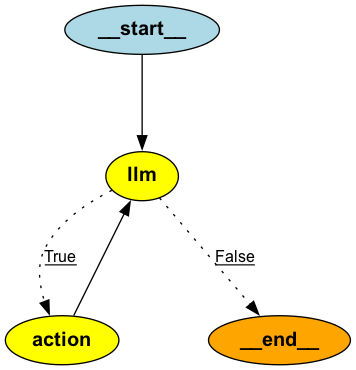

In [33]:
from IPython.display import Image
Image(abot.graph.get_graph().draw_png())

In [34]:
messages = [HumanMessage(content="What is the weather in California?")]
result = abot.graph.invoke({"messages": messages})

Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'weather in California'}, 'id': 'f4ab0546-a71a-4424-95f5-df27e9727e5b', 'type': 'tool_call'}
Back to the model!


In [35]:
result

{'messages': [HumanMessage(content='What is the weather in California?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'tavily_search_results_json', 'arguments': '{"query": "weather in California"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--23845f61-21d5-4752-a20a-b19adc1c9340-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'weather in California'}, 'id': 'f4ab0546-a71a-4424-95f5-df27e9727e5b', 'type': 'tool_call'}], usage_metadata={'input_tokens': 147, 'output_tokens': 92, 'total_tokens': 239, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 69}}),
  ToolMessage(content="[{'title': 'Weather in Los Angeles in October 2025 (California)', 'url': 'https://world-weather.info/forecast/usa/los_angeles/october-2025/', 'content': '+64°\\n\\n

In [36]:
print(result['messages'][-1].content)

The provided weather forecast is for October 2025 in Los Angeles and Orange County, California. It is not the current weather.

In Los Angeles for October 2025, temperatures are generally in the high 60s to mid-70s Fahrenheit (around 18-25°C) during the day, with lows in the high 50s to mid-60s Fahrenheit (around 15-18°C). Wind speeds are typically around 5-6 mph.

In Orange County for October 2025, temperatures range from lows of 60-68°F (16-20°C) to highs of 68-84°F (20-29°C). There is a very low rain risk (0-20%).


In [37]:
query = "Who won the super bowl in 2024? In what state is the winning team headquarters located? \
What is the GDP of that state? Answer each question." 

messages = [HumanMessage(content=query)]
result = abot.graph.invoke({"messages": messages})

Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'who won super bowl 2024'}, 'id': '94ef7489-5a20-4d78-9acc-a9025d6586f0', 'type': 'tool_call'}
Back to the model!
Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'Kansas City Chiefs headquarters state'}, 'id': '239e8873-6f62-4a61-ad17-3021cec823e1', 'type': 'tool_call'}
Back to the model!
Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'GDP of Missouri'}, 'id': '788b63c3-b7a9-47fa-8499-5f5959d0ce7c', 'type': 'tool_call'}
Back to the model!


In [38]:
result

{'messages': [HumanMessage(content='Who won the super bowl in 2024? In what state is the winning team headquarters located? What is the GDP of that state? Answer each question.', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'tavily_search_results_json', 'arguments': '{"query": "who won super bowl 2024"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--e22d3b66-730f-4cd9-a53f-d2ae91217e47-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'who won super bowl 2024'}, 'id': '94ef7489-5a20-4d78-9acc-a9025d6586f0', 'type': 'tool_call'}], usage_metadata={'input_tokens': 174, 'output_tokens': 155, 'total_tokens': 329, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 126}}),
  ToolMessage(content='[{\'title\': \'Who won the 2024 Super Bowl? Looking 

In [39]:
print(result['messages'][-1].content)

The Kansas City Chiefs won Super Bowl LVIII in 2024. Their headquarters are located in Missouri. The GDP of Missouri in 2024 was $356.7 billion.
